# Energy Price Prediction Pipeline

This notebook implements a modular machine learning pipeline for predicting 24-hour ahead energy price movements using news signals and energy market data.

## Pipeline Stages
1. **Setup & Configuration** - Initialize system and configure compute
2. **Data Ingestion** - Load news and energy data
3. **News Processing** - Extract text features and embeddings
4. **Feature Engineering** - Time-decay aggregation and PCA
5. **Parameter Optimization** - Grid search over decay parameters
6. **Model Training** - Train XGBoost/LightGBM models
7. **Evaluation** - Performance assessment and statistical testing

## 1. Setup & Imports

In [37]:
# Add scripts directory to path
import sys
from pathlib import Path
import importlib

# Navigate to scripts directory
scripts_dir = Path('../scripts').resolve()
config_dir = Path('../config').resolve()
sys.path.insert(0, str(scripts_dir.parent))

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom module imports
from config import pipeline_config as cfg
from config import model_config
from scripts import device_utils
from scripts import profiling
from scripts import data_ingestion
from scripts import feature_engineering as fe
from scripts import model_utils
from scripts import evaluation
from scripts import visualization

# Reload modules to pick up any changes
importlib.reload(device_utils)
importlib.reload(profiling)
importlib.reload(data_ingestion)
importlib.reload(fe)
importlib.reload(model_utils)
importlib.reload(evaluation)
importlib.reload(visualization)

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All modules imported and reloaded successfully")


✓ All modules imported and reloaded successfully


## 2. Configure Parameters

**Customize these parameters to tune the pipeline behavior:**

In [2]:
# ============================================================================
# CONFIGURABLE PARAMETERS - MODIFY THESE AS NEEDED
# ============================================================================

# Time-series parameters
FORECAST_HORIZON = cfg.FORECAST_HORIZON_HOURS  # 24 hours
LOOKBACK_WINDOW = cfg.DEFAULT_LOOKBACK_WINDOW  # 336 hours (2 weeks)
TIME_DECAY_LAMBDA = cfg.DEFAULT_DECAY_LAMBDA   # 0.05

# Target definition
SPREAD_DEADBAND = cfg.SPREAD_TARGET_DEADBAND   # 5.0 EUR/MWh

# Data splits
TRAIN_RATIO = cfg.TRAIN_RATIO  # 0.7
VAL_RATIO = cfg.VAL_RATIO      # 0.2
TEST_RATIO = cfg.TEST_RATIO    # 0.1

# Feature engineering
PCA_COMPONENTS = cfg.PCA_COMPONENTS  # 50
USE_UMAP = True  # Use UMAP for dimensionality reduction (False = PCA only)

# Cross-validation
N_CV_SPLITS = cfg.N_CV_SPLITS  # 5
CV_STEP_SIZE = cfg.CV_STEP_SIZE_HOURS  # 24

# Grid search ranges
LOOKBACK_WINDOWS = cfg.LOOKBACK_WINDOWS  # [168, 336, 504]
TIME_DECAY_LAMBDAS = cfg.TIME_DECAY_LAMBDAS  # [0.01, 0.05, 0.1]

# Random search
XGB_RANDOM_SEARCH_ITERS = cfg.XGB_RANDOM_SEARCH_ITERS  # 80 iterations by default

# Data paths (relative to data directory)
NEWS_PATH = "../data/german_news_v1.csv"
ENERGY_PATH = "../data/energy_data.csv"

print("✓ Configuration loaded")
print(f"  Forecast horizon: {FORECAST_HORIZON} hours")
print(f"  Lookback window: {LOOKBACK_WINDOW} hours")
print(f"  Time decay lambda: {TIME_DECAY_LAMBDA}")
print(f"  Spread deadband: {SPREAD_DEADBAND} EUR/MWh")

✓ Configuration loaded
  Forecast horizon: 24 hours
  Lookback window: 336 hours
  Time decay lambda: 0.05
  Spread deadband: 7.0 EUR/MWh


## 3. Initialize System & Detect Compute Device

In [3]:
# Detect available compute device (GPU/CPU)
device_config = device_utils.detect_compute_device(task='general', verbose=True)

print(f"\n✓ Using device: {device_config['description']}")
print(f"  Optimal batch size: {device_config['optimal_batch_size']}")

✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)

✓ Using device: Apple MPS GPU
  Optimal batch size: 128


## 4. Stage 1: Data Ingestion

In [4]:
with profiling.StageProfiler("Stage 1: Data Ingestion", device_config):
    ingestion_results = data_ingestion.run_ingestion_stage(
        news_path=NEWS_PATH,
        energy_path=ENERGY_PATH,
        min_timestamp=cfg.MIN_TIMESTAMP,
        news_sample=600,  # Set to integer for testing with smaller dataset
        forecast_horizon=FORECAST_HORIZON,
        spread_deadband=SPREAD_DEADBAND,
        random_state=cfg.RANDOM_STATE,
    )

news_df = ingestion_results['news_df']
energy_df = ingestion_results['energy_df']
master_df = ingestion_results['master_df']

print(f"\n✓ Data loaded successfully")
print(f"  News articles: {len(news_df)}")
print(f"  Energy records: {len(energy_df)}")
print(f"  Master records: {len(master_df)}")


[Stage ⏳] Stage 1: Data Ingestion — starting
News shape after filters: (600, 4)
Energy telemetry shape: (7462, 5)
Baseline feature frame: (7270, 16)
[Stage ✅] Stage 1: Data Ingestion — completed in 0.70s
  CPU usage: 34.2% • IO wait: 0.00%
  Disk Δ: +52.3 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Data loaded successfully
  News articles: 600
  Energy records: 7462
  Master records: 7270


### Inspect Data

In [5]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    2707
 1.0    2614
 0.0    1949
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    37.235213
 1.0    35.955983
 0.0    26.808803
Name: proportion, dtype: float64


# Plot comprehensive EDA dashboard

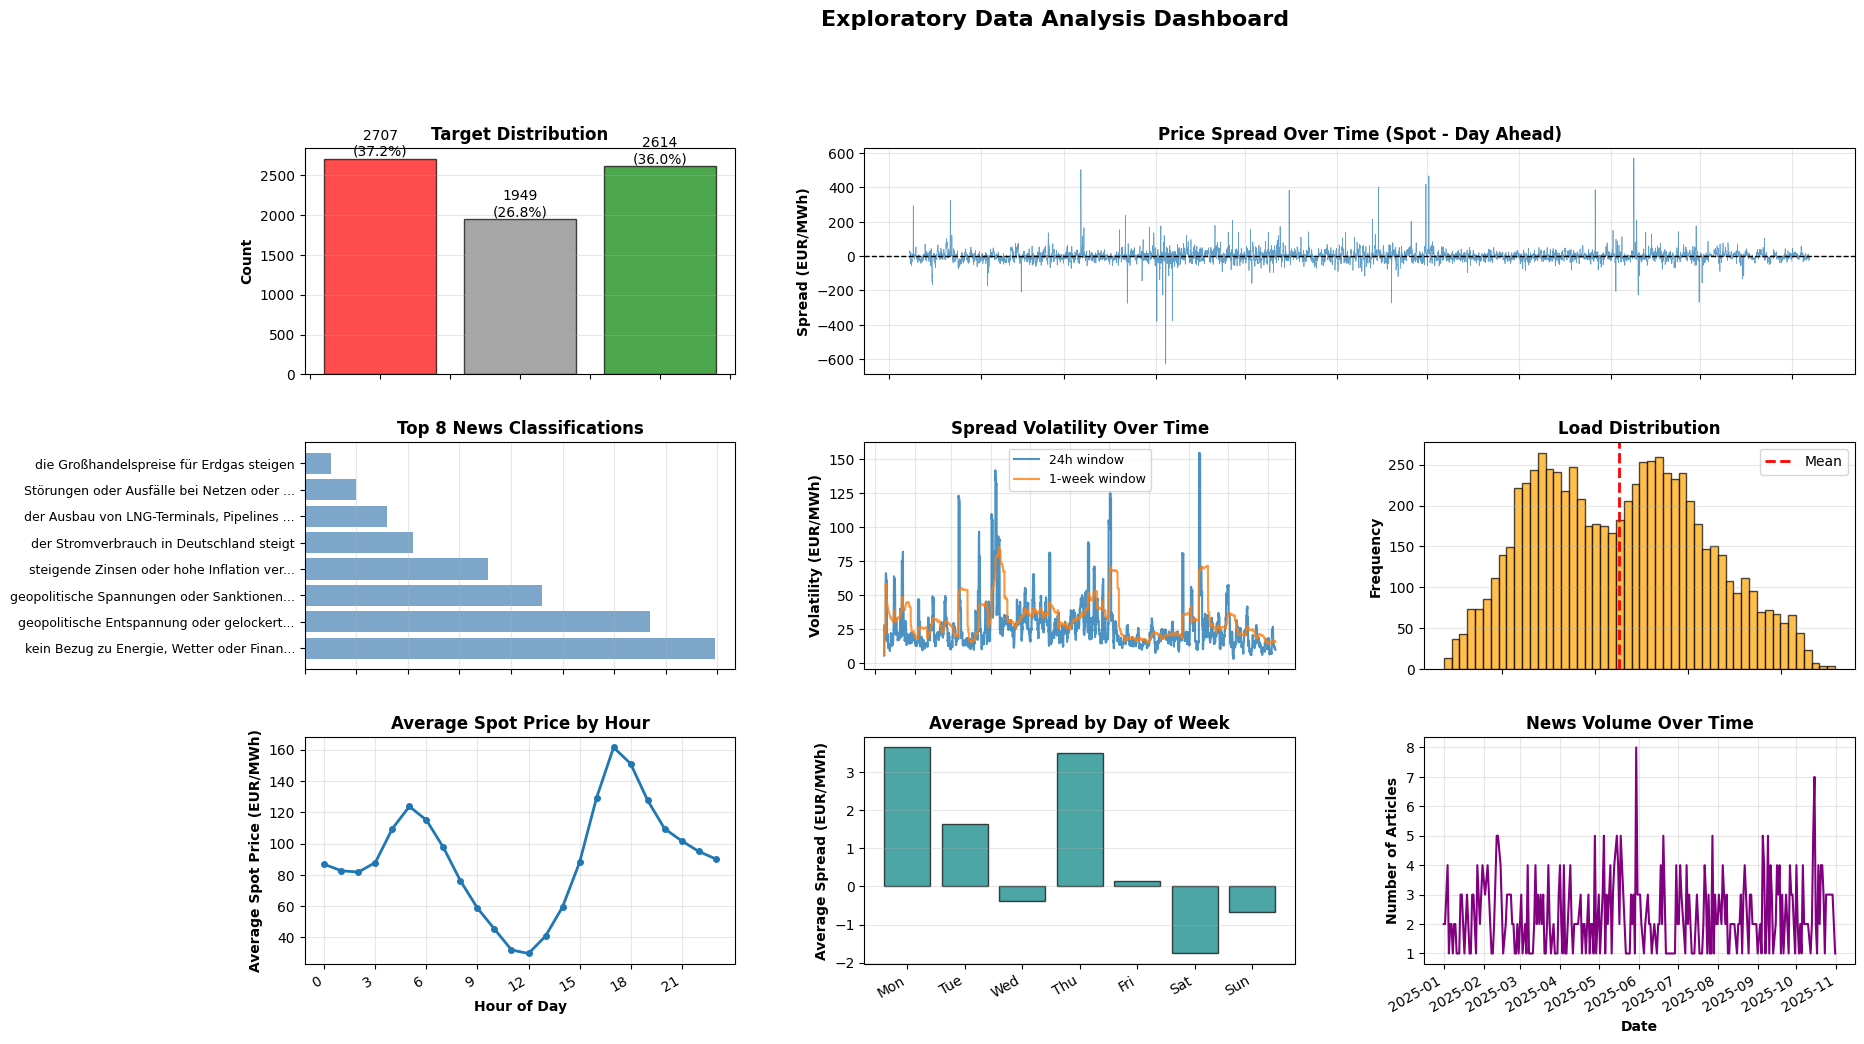

In [38]:
visualization.plot_eda_dashboard(master_df=master_df,news_df=news_df)

## 5. Stage 2: News Processing - Topic Classification

We now route articles hierarchically with `MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7`. Stage-1 assigns a coarse category (e.g. Nachfrage, Angebot, Geopolitik), and Stage-2 refines to the existing leaf topics that drive downstream features. Low-confidence articles fall back to the catch-all topic so feature engineering remains backward compatible.

In [7]:
with profiling.StageProfiler("Stage 2A: Zero-Shot Topic Classification", device_config):
    embedding_results = fe.run_embedding_stage(
        news_df=news_df,
        candidate_labels=cfg.CANDIDATE_LABELS,
        hypothesis_template=cfg.HYPOTHESIS_TEMPLATE,
        device_config=device_config,
        batch_size=device_config['optimal_batch_size'],
        model_name=cfg.ZEROSHOT_MODEL,
        hierarchical_topic_groups=cfg.HIERARCHICAL_TOPIC_GROUPS,
        routing_settings=cfg.HIERARCHICAL_ROUTING_SETTINGS,
    )

news_df = embedding_results['news_df']

print(f"\n✓ Topic classification completed")
print(f"  Device used: {embedding_results['hf_device']}")
print(f"  Batch size: {embedding_results['batch_size']}")
if 'classification_stage1' in news_df.columns:
    print(f"  Stage-1 categories detected: {news_df['classification_stage1'].nunique()}")


[Stage ⏳] Stage 2A: Zero-Shot Topic Classification — starting


Device set to use mps


Processing 600 texts with batch_size=128
Processing 169 texts with batch_size=128
Processing 34 texts with batch_size=128
Processing 68 texts with batch_size=128
Processing 12 texts with batch_size=128
Processing 9 texts with batch_size=128
Processing 17 texts with batch_size=128
Processing 292 texts with batch_size=128
Processing 9 texts with batch_size=128
Processing 57 texts with batch_size=128
Processing 29 texts with batch_size=128
Processing 33 texts with batch_size=128
Processing 5 texts with batch_size=128
Processing 1 texts with batch_size=128
Classification completed: 600 articles processed
Articles classified as 'other': 159 (26.5%)

Classification distribution:
classification
kein Bezug zu Energie, Wetter oder Finanzmärkten                                     159
geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken      134
geopolitische Spannungen oder Sanktionen verschärfen die Energieversorgung            92
steigende Zinsen oder hohe Inflation

## 6. Stage 2B: Sentence Embeddings

In [8]:
with profiling.StageProfiler("Stage 2B: Sentence Embeddings", device_config):
    news_df = fe.compute_embeddings(
        news_df=news_df,
        device_config=device_config,
        model_name=cfg.EMBEDDING_MODEL,
        batch_size=device_config['optimal_batch_size'],
        show_progress=True,
        cache_dir=Path('../outputs/.cache/embeddings'),
    )

print(f"\n✓ Embeddings computed")
print(f"  Embedding dimension: {len(news_df.iloc[0]['embedding'])}")


[Stage ⏳] Stage 2B: Sentence Embeddings — starting
Loaded embeddings from cache (../outputs/.cache/embeddings/news_embeddings.parquet)
[Stage ✅] Stage 2B: Sentence Embeddings — completed in 0.21s
  CPU usage: 47.9% • IO wait: 0.00%
  Disk Δ: +141.0 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Embeddings computed
  Embedding dimension: 384


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


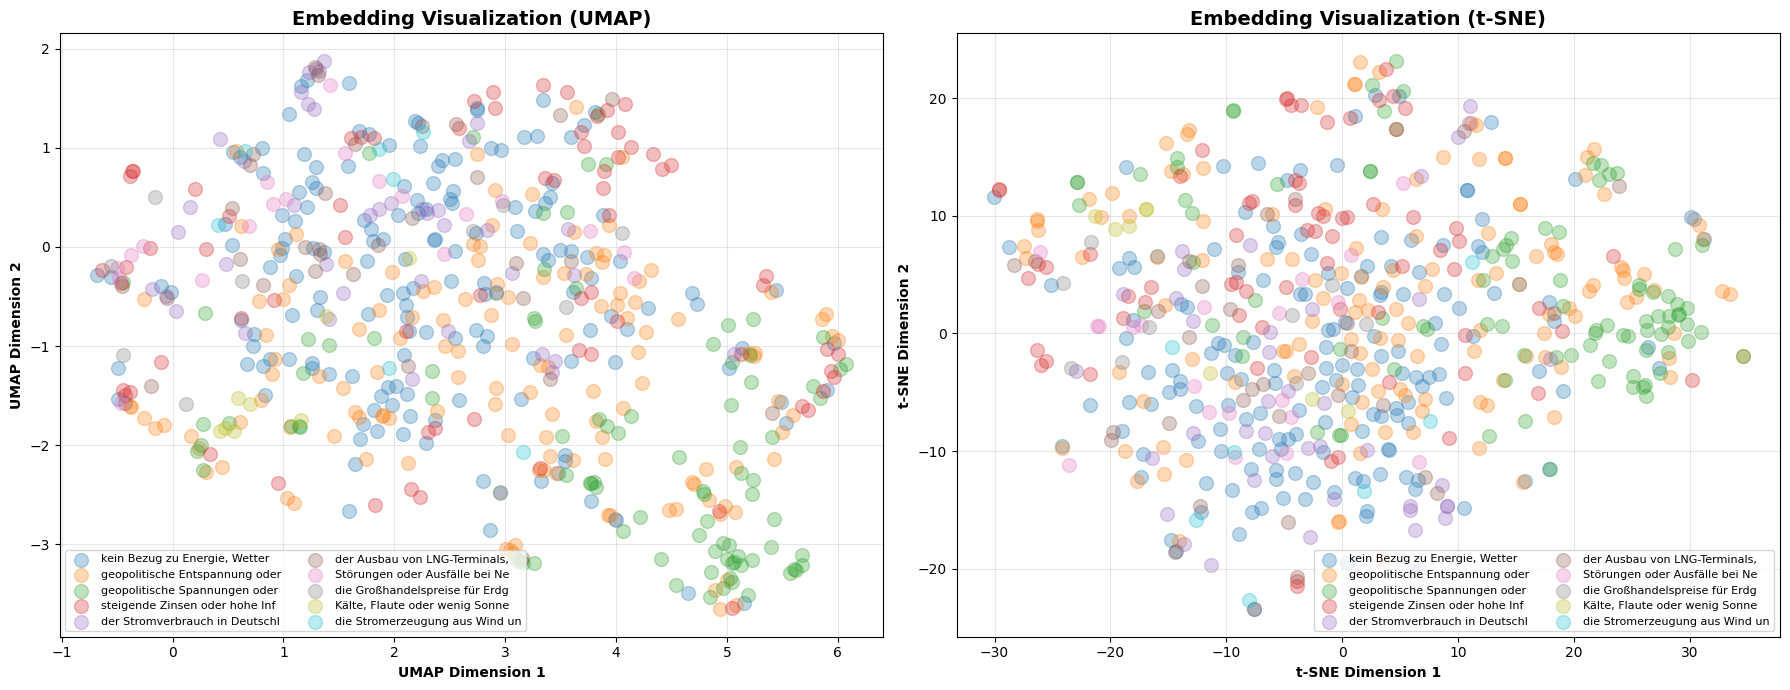

In [9]:
visualization.plot_embedding_quality(news_df=news_df, n_samples=2000, perplexity=30)

## 7. Stage 3: Feature Engineering - Time-Decay Aggregation

In [10]:
with profiling.StageProfiler("Stage 3A: Time-Decay Feature Precomputation", device_config):
    feature_cache = fe.precompute_time_decay_feature_sets(
        news_df=news_df,
        master_df=master_df,
        lookback_windows=LOOKBACK_WINDOWS,
        decay_lambdas=TIME_DECAY_LAMBDAS,
        n_components=PCA_COMPONENTS,
        use_umap=USE_UMAP,
        random_state=cfg.RANDOM_STATE,
        device_config=device_config,
        verbose=True,
    )

print(f"\n✓ Time-decay feature cache built")
print(f"  Parameter combinations: {len(feature_cache)}")
print(f"  Sample keys: {list(feature_cache.keys())[:3]}")


[Stage ⏳] Stage 3A: Time-Decay Feature Precomputation — starting
Precomputing time-decayed features for 30 parameter combinations...
[1/30] lookback=24h, decay_lambda=0.01
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.01_reduction.parquet)
[2/30] lookback=24h, decay_lambda=0.05
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.05_reduction.parquet)
[3/30] lookback=24h, decay_lambda=0.1
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.1_reduction.parquet)
[4/30] lookback=24h, decay_lambda=0.25
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.25_reduction.parquet)
[5/30] lookback=24h, decay_lambda=0.5
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.5_reduction.parquet)
[6/30] lookback=48h, decay_lambda=0.01
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.01_reduction.parquet)
[7/30] lookback=48h, decay_lam

In [11]:
with profiling.StageProfiler("Stage 3B: Dataset Assembly", device_config):
    preprocessed_datasets = fe.assemble_time_decay_datasets(
        master_df=master_df,
        feature_cache=feature_cache,
        target_column=cfg.TARGET_COLUMN,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO,
        dataset_prefix="td_dataset",
    )

sample_params_key = next(iter(preprocessed_datasets))
sample_dataset = preprocessed_datasets[sample_params_key]

print(f"\n✓ Dataset assembly complete")
print(f"  Prepared datasets: {len(preprocessed_datasets)}")
print(
    f"  Sample dataset: {sample_dataset['dataset_name']} -> "
    f"train={len(sample_dataset['train_df'])}, "
    f"val={len(sample_dataset['val_df'])}, "
    f"test={len(sample_dataset['test_df'])}"
)


[Stage ⏳] Stage 3B: Dataset Assembly — starting
[Stage ✅] Stage 3B: Dataset Assembly — completed in 0.09s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +8.0 MB read, +1.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset assembly complete
  Prepared datasets: 30
  Sample dataset: td_dataset_lw24_dl0.01 -> train=5089, val=1454, test=727


## 8. Stage 3C: Dataset Scaling & Summary

In [12]:
with profiling.StageProfiler("Stage 3C: Dataset Scaling", device_config):
    preprocessed_datasets = fe.scale_preprocessed_datasets(preprocessed_datasets)

sample_dataset = preprocessed_datasets[sample_params_key]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"\n✓ Dataset scaling complete")
print(f"  Scaled news features per dataset: {len(scaled_news_features)}")
print(f"  Sample scaled features: {scaled_news_features[:5]}")


[Stage ⏳] Stage 3C: Dataset Scaling — starting
[Stage ✅] Stage 3C: Dataset Scaling — completed in 0.50s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +20.9 MB read, +46.7 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset scaling complete
  Scaled news features per dataset: 65
  Sample scaled features: ['kein Bezug zu Energie, Wetter oder Finanzmärkten_scaled', 'steigende Zinsen oder hohe Inflation verschärfen die Marktlage_scaled', 'geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken_scaled', 'Störungen oder Ausfälle bei Netzen oder Kraftwerken verringern das Angebot_scaled', 'der Stromverbrauch in Deutschland steigt_scaled']


## 9. Stage 3D: Feature Selection with RidgeCV

In [13]:
# Define baseline (price + temporal) features
baseline_features = [
    "Spot Price", "Day Ahead Auction", "real_spread_abs",
    "price_lag_24", "price_lag_168", "Load", "load_lag_24", "load_lag_168",
    "hour", "day_of_week", "day_of_year", "week_of_year", "month",
]

# Get news feature definitions from sample dataset
topic_features = sample_dataset["topic_features"]
embedding_features = sample_dataset["embedding_features"]
news_features = sample_dataset["news_features"]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"✓ Feature sets defined")
print(f"  Baseline: {len(baseline_features)}, Topics: {len(topic_features)}, Embeddings: {len(embedding_features)}, Total news: {len(news_features)}")

# Run Ridge feature selection across parameter combinations
with profiling.StageProfiler("Stage 3D: Ridge Feature Selection", device_config):
    top_3_combinations = fe.grid_search_time_decay_params(
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        alphas=cfg.DEFAULT_ALPHAS,
        max_splits=cfg.N_CV_SPLITS,
    )

if top_3_combinations:
    best_params_key = top_3_combinations[0]["params_key"]
    best_dataset = preprocessed_datasets[best_params_key]
    print(f"\n✓ Top parameter combination: {best_dataset['dataset_name']} (lookback={top_3_combinations[0]['lookback_window']}h, lambda={top_3_combinations[0]['decay_lambda']})")
else:
    best_params_key = None
    best_dataset = None
    print("\n⚠ No valid parameter combinations identified. Review grid search configuration.")

✓ Feature sets defined
  Baseline: 13, Topics: 15, Embeddings: 50, Total news: 65

[Stage ⏳] Stage 3D: Ridge Feature Selection — starting
Grid searching 30 parameter combinations...
Using expanding-window RidgeCV confined to training splits (target: spread_target_shift_24)
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:    9.9s remaining:    5.7s
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:   10.1s remaining:    3.1s


TOP 3 PARAMETER COMBINATIONS:
1. dataset=td_dataset_lw48_dl0.25 | lookback=48h | lambda=0.25 | alpha=3.1623 | Val Accuracy=0.425 | Val Macro-F1=0.361
2. dataset=td_dataset_lw168_dl0.01 | lookback=168h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.424 | Val Macro-F1=0.370
3. dataset=td_dataset_lw504_dl0.1 | lookback=504h | lambda=0.1 | alpha=100.0000 | Val Accuracy=0.411 | Val Macro-F1=0.367
[Stage ✅] Stage 3D: Ridge Feature Selection — completed in 10.46s
  CPU usage: 78.6% • IO wait: 0.00%
  Disk Δ: +586.0 MB read, +1904.4 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Top parameter combination: td_dataset_lw48_dl0.25 (lookback=48h, lambda=0.25)


[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:   10.3s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:   10.3s finished


## 10. Stage 3E: Summarise Ridge Results

In [14]:
# Display top 3 Ridge parameter combinations
if top_3_combinations:
    top_3_summary = pd.DataFrame([{
        "dataset_name": res["dataset_name"],
        "lookback_window": res["lookback_window"],
        "decay_lambda": res["decay_lambda"],
        "alpha": res["best_alpha"],
        "val_accuracy": res["val_accuracy"],
        "val_macro_f1": res["val_macro_f1"],
    } for res in top_3_combinations])
    display(top_3_summary)
else:
    print("No RidgeCV results available to summarise.")

,dataset_name,lookback_window,decay_lambda,alpha,val_accuracy,val_macro_f1
0,td_dataset_lw48_dl0.25,48,0.25,3.162278,0.425034,0.360947
1,td_dataset_lw168_dl0.01,168,0.01,1000.000000,0.423659,0.370439
2,td_dataset_lw504_dl0.1,504,0.10,100.000000,0.411279,0.367197


## 11. Stage 4: Model Training - XGBoost with Random Search

**Note:** This section demonstrates XGBoost training with hyperparameter tuning (default `n_iter=80`). Adjust `n_iter` and CV parameters based on your computational resources.

In [15]:
with profiling.StageProfiler("Stage 4: XGBoost Random Search", device_config):
    xgb_results = model_utils.train_xgb_candidates(
        top_combinations=top_3_combinations if top_3_combinations else [],
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        param_distributions=cfg.XGB_PARAM_DISTRIBUTIONS,
        n_iter=XGB_RANDOM_SEARCH_ITERS,
        random_state=cfg.RANDOM_STATE,
        n_splits=cfg.DEFAULT_EXPANDING_SPLITS,
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=device_config,
        fallback_params_key=sample_params_key if not top_3_combinations else None,
        fallback_dataset=sample_dataset if not top_3_combinations else None
    )

# Extract results
xgb_tuning_runs = xgb_results["tuning_runs"]
xgb_best_models = xgb_results["best_models"]
xgb_feature_columns = xgb_results["feature_columns"]
xgb_label_encoders = xgb_results["label_encoders"]
best_xgb_run = xgb_results["best_run"]
best_xgb_params_key = xgb_results["best_params_key"]
best_xgb_model = xgb_results["best_model"]
best_xgb_feature_columns = xgb_results["best_feature_columns"]
best_xgb_label_encoder = xgb_results["best_label_encoder"]
best_dataset = xgb_results["best_dataset"]


[Stage ⏳] Stage 4: XGBoost Random Search — starting
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 80 candidates, totalling 320 fits
#1 td_dataset_lw48_dl0.25 → CV F1=0.424, Val Acc=0.457, Val Macro-F1=0.440
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 80 candidates, totalling 320 fits
#2 td_dataset_lw168_dl0.01 → CV F1=0.346, Val Acc=0.472, Val Macro-F1=0.454
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 80 candidates, totalling 320 fits
#3 td_dataset_lw504_dl0.1 → CV F1=0.369, Val Acc=0.435, Val Macro-F1=0.414

✓ Selected XGBoost dataset td_dataset_lw48_dl0.25 (lookback=48h, lambda=0.25)
  Best CV macro-F1: 0.424
  Validation macro-F1: 0.440
  XGBoost classes: [-1  0  1]
[Stage ✅] Stage 4: XGBoost Random Search 

In [16]:
# Threshold tuning for XGBoost positive class (label = 1)
from sklearn.metrics import f1_score

xgb_positive_class_label = 1
class_indices = np.where(best_xgb_label_encoder.classes_ == xgb_positive_class_label)[0]
if len(class_indices) == 0:
    raise ValueError(
        f"Positive class label {xgb_positive_class_label} not found in XGBoost label encoder classes {best_xgb_label_encoder.classes_}."
    )
xgb_positive_class_index = int(class_indices[0])

X_val_xgb = best_dataset["val_df"][best_xgb_feature_columns].fillna(0)
y_val_xgb = best_xgb_label_encoder.transform(
    best_dataset["val_df"][cfg.TARGET_COLUMN].astype(int)
)
val_proba_xgb = best_xgb_model.predict_proba(X_val_xgb)

xgb_opt_threshold, xgb_opt_metric = model_utils.optimize_classification_threshold(
    y_true=y_val_xgb,
    y_proba=val_proba_xgb,
    metric="f1",
    class_of_interest=xgb_positive_class_index,
)

xgb_val_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=val_proba_xgb,
    threshold=xgb_opt_threshold,
    class_of_interest=xgb_positive_class_index,
)

xgb_val_macro_f1_threshold = f1_score(
    y_val_xgb,
    xgb_val_pred_threshold,
    average="macro",
    zero_division=0,
)

print("✓ XGBoost threshold tuning complete")
print(f"  Positive class label: {xgb_positive_class_label} → encoder index {xgb_positive_class_index}")
print(f"  Optimal threshold (validation): {xgb_opt_threshold:.3f}")
print(f"  Validation Macro-F1 (thresholded): {xgb_val_macro_f1_threshold:.3f}")



THRESHOLD OPTIMIZATION
Metric: f1
Optimised class index: 2 (of 3 classes)
Optimal threshold: 0.300
Best f1: 0.5163
Default (0.5) f1: 0.3039

✓ XGBoost threshold tuning complete
  Positive class label: 1 → encoder index 2
  Optimal threshold (validation): 0.300
  Validation Macro-F1 (thresholded): 0.380



COMPUTING LEARNING CURVES FOR XGBOOST 3-CLASS CLASSIFIER
This may take a few minutes...


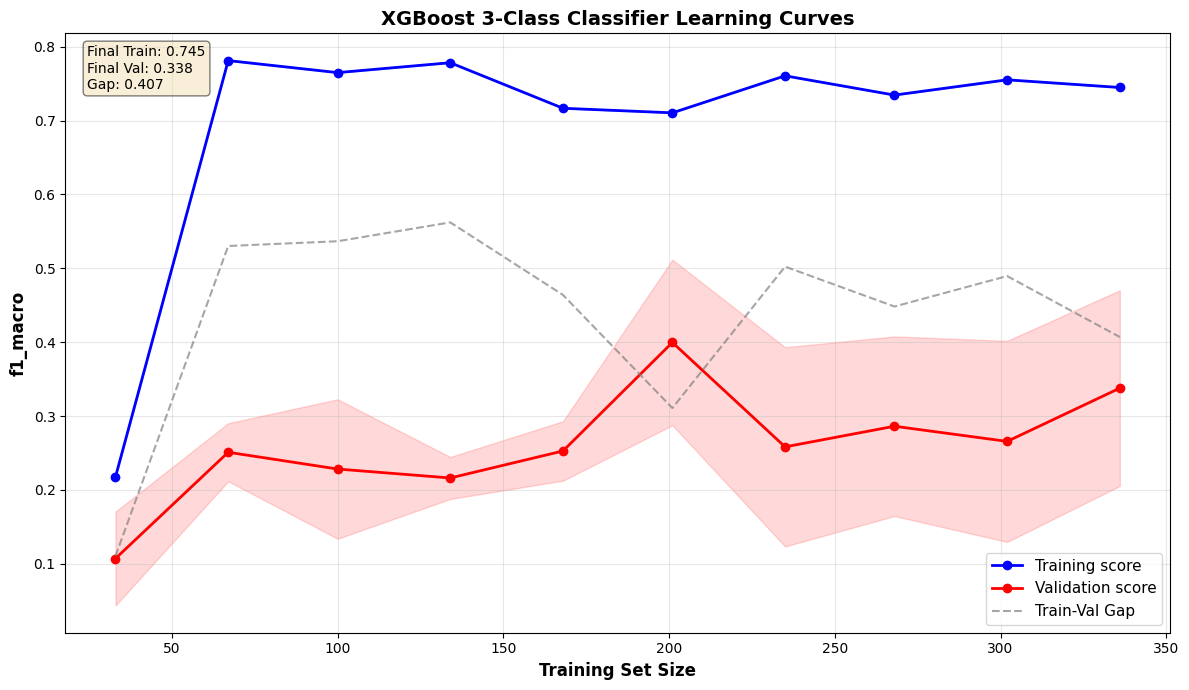

✓ Learning curves complete
  Final training score: 0.7448
  Final validation score: 0.3378
  Train-val gap: 0.4070
  ⚠ Warning: Large gap suggests overfitting



In [17]:
# Learning curves for best XGBoost model
if best_xgb_run is not None:
    from sklearn.base import clone
    
    # Recreate a fresh estimator with the same parameters
    xgb_for_learning_curve = clone(best_xgb_model)
    xgb_for_learning_curve.set_params(**best_xgb_run['best_params'])
    
    # Create CV splitter
    lc_cv = model_utils.ExpandingWindowSplitter(
        n_splits=3,  # Use fewer splits for speed
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
    )
    
    # Prepare data with 3-class encoding
    X_train_xgb = best_dataset['train_df'][best_xgb_feature_columns].fillna(0)
    y_train_xgb = best_xgb_label_encoder.transform(
        best_dataset['train_df'][cfg.TARGET_COLUMN].astype(int)
    )
    
    visualization.plot_learning_curves(
        model=xgb_for_learning_curve,
        X_train=X_train_xgb,
        y_train=y_train_xgb,
        cv_splitter=lc_cv,
        scoring='f1_macro',
        model_name='XGBoost 3-Class Classifier'
    )

## 12. Stage 5: Model Evaluation

In [18]:
from sklearn.metrics import accuracy_score, f1_score

if best_xgb_model is None:
    raise RuntimeError("XGBoost model not available. Please rerun Stage 4.")

# Prepare test data
test_dataset = best_dataset
X_test = test_dataset["test_df"][best_xgb_feature_columns].fillna(0)
y_test_raw = test_dataset["test_df"][cfg.TARGET_COLUMN].astype(int)
y_test = best_xgb_label_encoder.transform(y_test_raw)

# Evaluate model probabilities
y_pred_proba = best_xgb_model.predict_proba(X_test)
y_pred_default = np.argmax(y_pred_proba, axis=1)

xgb_test_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=y_pred_proba,
    threshold=xgb_opt_threshold,
    class_of_interest=xgb_positive_class_index,
)

# Metrics without and with threshold tuning
xgb_test_accuracy_default = accuracy_score(y_test, y_pred_default)
xgb_test_macro_f1_default = f1_score(y_test, y_pred_default, average="macro", zero_division=0)

test_accuracy = accuracy_score(y_test, xgb_test_pred_threshold)
test_macro_f1 = f1_score(y_test, xgb_test_pred_threshold, average="macro", zero_division=0)

print(f"\n✓ XGBoost Test Evaluation (3-class)")
print(f"  Default (argmax) → Acc={xgb_test_accuracy_default:.4f}, Macro-F1={xgb_test_macro_f1_default:.4f}")
print(f"  Thresholded      → Acc={test_accuracy:.4f}, Macro-F1={test_macro_f1:.4f}")

# Display detailed class-wise metrics for thresholded predictions
model_utils.print_class_wise_metrics(
    y_true=y_test,
    y_pred=xgb_test_pred_threshold,
    label_encoder=best_xgb_label_encoder,
    dataset_name="XGBoost Test Set (Thresholded)"
)


✓ XGBoost Test Evaluation (3-class)
  Default (argmax) → Acc=0.3783, Macro-F1=0.3633
  Thresholded      → Acc=0.4182, Macro-F1=0.3643

CLASS-WISE METRICS: XGBoost Test Set (Thresholded)

Confusion Matrix:
[[ 94   8 110]
 [ 68  20 174]
 [ 59   4 190]]

Per-Class Recall:
  Class -1: 0.443 (94/212)
  Class 0: 0.076 (20/262)
  Class 1: 0.751 (190/253)

Classification Report:
              precision    recall  f1-score   support

          -1       0.43      0.44      0.43       212
           0       0.62      0.08      0.14       262
           1       0.40      0.75      0.52       253

    accuracy                           0.42       727
   macro avg       0.48      0.42      0.36       727
weighted avg       0.49      0.42      0.36       727


Predictions per class:
  Class -1: 221 predictions (30.4%)
  Class 0: 32 predictions (4.4%)
  Class 1: 474 predictions (65.2%)



## 13. Visualizations

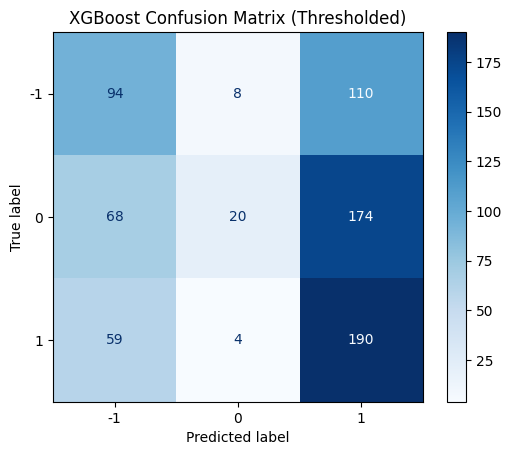

In [19]:
# Confusion matrix (3-class)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb_test_pred_threshold)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_xgb_label_encoder.classes_
)
disp.plot(cmap='Blues', values_format='d')
plt.title('XGBoost Confusion Matrix (Thresholded)')
plt.show()


/Users/nicolas/Desktop/Repos/zhaw_arep/final_methodology_refactored/scripts/visualization.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


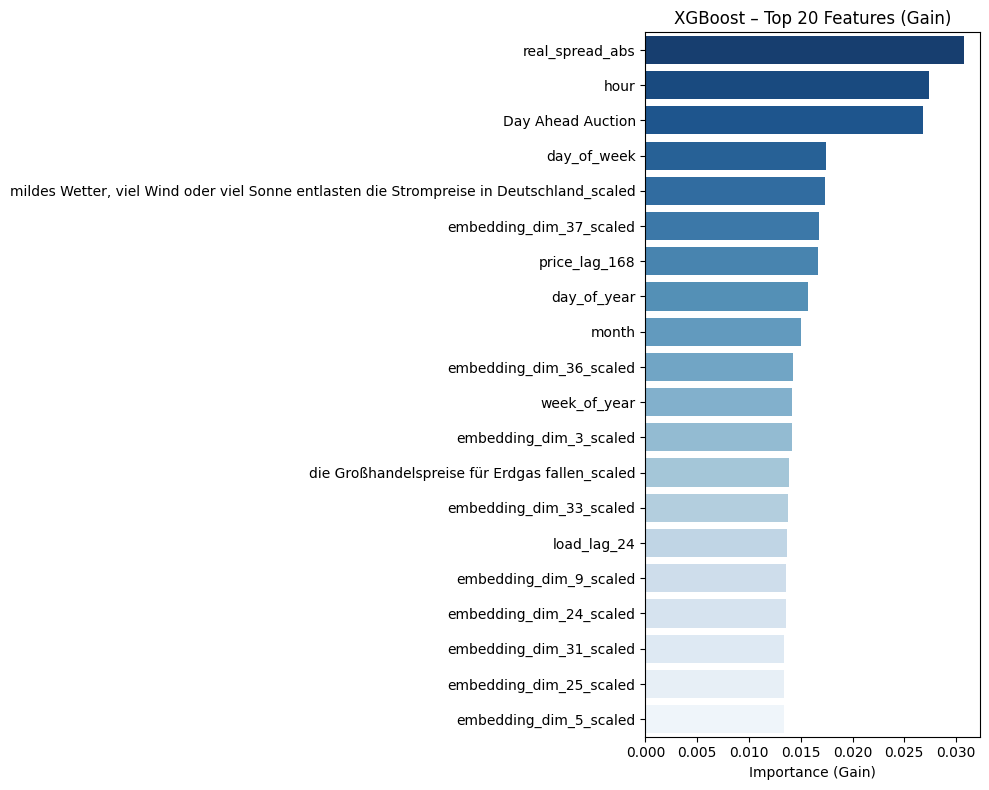

In [20]:
# Feature importance
importance_df = visualization.plot_feature_importance(
    model=best_xgb_model,
    feature_names=best_xgb_feature_columns,
    model_name="XGBoost",
    top_n=20
)

## 14. Stage 6: LightGBM Signal Modelling


In [21]:
if best_xgb_model is None or best_dataset is None:
    raise RuntimeError("XGBoost model and dataset must be available before training LightGBM.")

# Prepare datasets for LightGBM using helper function
lgbm_prep = model_utils.prepare_lgbm_datasets(
    best_xgb_model=best_xgb_model,
    best_dataset=best_dataset,
    best_xgb_feature_columns=best_xgb_feature_columns,
    baseline_features=baseline_features,
    target_column=cfg.TARGET_COLUMN,
    prediction_prefix="xgb"
)

signal_train_df = lgbm_prep["train_df"]
signal_val_df = lgbm_prep["val_df"]
signal_test_df = lgbm_prep["test_df"]
signal_feature_columns = lgbm_prep["signal_feature_columns"]
baseline_feature_columns = lgbm_prep["baseline_feature_columns"]
xgb_feature_names = lgbm_prep["xgb_feature_names"]

print("✓ Prepared LightGBM datasets with XGBoost features")
print(f"  Signal feature count: {len(signal_feature_columns)}")
print(f"  Baseline feature count: {len(baseline_feature_columns)}")
print(f"  XGBoost features added: {xgb_feature_names}")


✓ Prepared LightGBM datasets with XGBoost features
  Signal feature count: 81
  Baseline feature count: 13
  XGBoost features added: ['xgb_prob_class0', 'xgb_prob_class1', 'xgb_pred']


In [22]:
# Prepare and encode targets for LightGBM
target_prep = model_utils.prepare_lgbm_targets(
    train_df=signal_train_df,
    val_df=signal_val_df,
    test_df=signal_test_df,
    target_column=cfg.TARGET_COLUMN
)

y_train_signal = target_prep["y_train"]
y_val_signal = target_prep["y_val"]
y_test_signal = target_prep["y_test"]
label_encoder = target_prep["label_encoder"]

print("✓ Encoded LightGBM targets")
print(
    "  Classes:",
    dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
)


✓ Encoded LightGBM targets
  Classes: {np.int64(-1): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}


In [23]:
# Configure device for LightGBM
lgbm_device_config = device_utils.detect_compute_device(task='training', verbose=True)
print(f"LightGBM device: {lgbm_device_config.get('description')} • backend={lgbm_device_config.get('lgbm_device', lgbm_device_config.get('device'))} • jobs={lgbm_device_config.get('n_jobs')}")

# Train both signal and baseline LightGBM models (class imbalance handled via is_unbalance=True and class_weight='balanced')
with profiling.StageProfiler("Stage 6: LightGBM Signal & Baseline Models", device_config):
    lgbm_results = model_utils.train_lightgbm_pair(
        signal_train_df=signal_train_df,
        signal_val_df=signal_val_df,
        signal_test_df=signal_test_df,
        signal_feature_columns=signal_feature_columns,
        baseline_feature_columns=baseline_feature_columns,
        y_train=y_train_signal,
        y_val=y_val_signal,
        y_test=y_test_signal,
        label_encoder=label_encoder,
        param_grid=model_config.LIGHTGBM_PARAM_GRID,
        n_cv_splits=cfg.N_CV_SPLITS,
        cv_step_size=cfg.DEFAULT_EXPANDING_STEP,
        cv_min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=lgbm_device_config,
        random_state=cfg.RANDOM_STATE
    )

# Extract trained models and artifacts
signal_best_lgbm = lgbm_results["signal_model"]
baseline_best_lgbm = lgbm_results["baseline_model"]
signal_column_rename_map = lgbm_results["signal_column_rename_map"]
baseline_column_rename_map = lgbm_results["baseline_column_rename_map"]
lgbm_artifacts = lgbm_results["evaluation"]
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]

✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)
LightGBM device: Apple MPS GPU • backend=cpu • jobs=6

[Stage ⏳] Stage 6: LightGBM Signal & Baseline Models — starting

TRAINING LIGHTGBM SIGNAL & BASELINE MODELS

Class distribution in training data:
  Class -1: 1985 samples (39.0%)
  Class 0: 1233 samples (24.2%)
  Class 1: 1871 samples (36.8%)

Training SIGNAL model (baseline + news features + XGBoost predictions)...

Class distribution in training data:
  Class 0: 1985 samples (39.0%) - Weight: 0.855
  Class 1: 1233 samples (24.2%) - Weight: 1.376
  Class 2: 1871 samples (36.8%) - Weight: 0.907
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✓ Signal model trained - Best CV macro-F1: 0.673
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

Training BASELINE model (price/temporal features onl

In [24]:
# Evaluate both models using helper function
lgbm_artifacts = model_utils.evaluate_lgbm_models(
    signal_model=signal_best_lgbm,
    baseline_model=baseline_best_lgbm,
    signal_feature_columns=signal_feature_columns,
    baseline_feature_columns=baseline_feature_columns,
    val_df=signal_val_df,
    test_df=signal_test_df,
    y_val=y_val_signal,
    y_test=y_test_signal,
    label_encoder=label_encoder,
    signal_column_rename_map=signal_column_rename_map,
    baseline_column_rename_map=baseline_column_rename_map,
)

# Extract artifacts for later use
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]


✓ LightGBM validation performance
  Signal model  → Acc=0.437, Macro-F1=0.427
  Baseline model → Acc=0.402, Macro-F1=0.324


In [25]:
# Threshold tuning for LightGBM models (positive class label = 1)
from sklearn.metrics import f1_score

lgbm_positive_class_label = 1
lgbm_class_indices = np.where(label_encoder.classes_ == lgbm_positive_class_label)[0]
if len(lgbm_class_indices) == 0:
    raise ValueError(
        f"Positive class label {lgbm_positive_class_label} not found in label encoder classes {label_encoder.classes_}."
    )
lgbm_positive_class_index = int(lgbm_class_indices[0])

signal_val_proba = lgbm_artifacts["signal"]["val_proba"]
baseline_val_proba = lgbm_artifacts["baseline"]["val_proba"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]

signal_opt_threshold, _ = model_utils.optimize_classification_threshold(
    y_true=y_val_signal,
    y_proba=signal_val_proba,
    metric="f1",
    class_of_interest=lgbm_positive_class_index,
)

baseline_opt_threshold, _ = model_utils.optimize_classification_threshold(
    y_true=y_val_signal,
    y_proba=baseline_val_proba,
    metric="f1",
    class_of_interest=lgbm_positive_class_index,
)

signal_val_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=signal_val_proba,
    threshold=signal_opt_threshold,
    class_of_interest=lgbm_positive_class_index,
)

baseline_val_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=baseline_val_proba,
    threshold=baseline_opt_threshold,
    class_of_interest=lgbm_positive_class_index,
)

signal_test_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=signal_test_proba,
    threshold=signal_opt_threshold,
    class_of_interest=lgbm_positive_class_index,
)

baseline_test_pred_threshold = model_utils.apply_threshold_to_probabilities(
    y_proba=baseline_test_proba,
    threshold=baseline_opt_threshold,
    class_of_interest=lgbm_positive_class_index,
)

signal_val_macro_f1_threshold = f1_score(
    y_val_signal,
    signal_val_pred_threshold,
    average="macro",
    zero_division=0,
)

baseline_val_macro_f1_threshold = f1_score(
    y_val_signal,
    baseline_val_pred_threshold,
    average="macro",
    zero_division=0,
)

print("✓ LightGBM threshold tuning complete")
print(f"  Positive class label: {lgbm_positive_class_label} → encoder index {lgbm_positive_class_index}")
print(f"  Signal threshold:   {signal_opt_threshold:.3f} (val Macro-F1={signal_val_macro_f1_threshold:.3f})")
print(f"  Baseline threshold: {baseline_opt_threshold:.3f} (val Macro-F1={baseline_val_macro_f1_threshold:.3f})")



THRESHOLD OPTIMIZATION
Metric: f1
Optimised class index: 2 (of 3 classes)
Optimal threshold: 0.250
Best f1: 0.5193
Default (0.5) f1: 0.3030


THRESHOLD OPTIMIZATION
Metric: f1
Optimised class index: 2 (of 3 classes)
Optimal threshold: 0.190
Best f1: 0.5087
Default (0.5) f1: 0.3065

✓ LightGBM threshold tuning complete
  Positive class label: 1 → encoder index 2
  Signal threshold:   0.250 (val Macro-F1=0.380)
  Baseline threshold: 0.190 (val Macro-F1=0.297)


In [26]:
from sklearn.metrics import accuracy_score, f1_score

signal_test_pred_default = lgbm_artifacts["signal"]["test_pred"]
baseline_test_pred_default = lgbm_artifacts["baseline"]["test_pred"]

signal_test_pred = signal_test_pred_threshold
baseline_test_pred = baseline_test_pred_threshold

signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

signal_test_accuracy_default = accuracy_score(y_test_signal, signal_test_pred_default)
signal_test_macro_f1_default = f1_score(y_test_signal, signal_test_pred_default, average="macro", zero_division=0)
baseline_test_accuracy_default = accuracy_score(y_test_signal, baseline_test_pred_default)
baseline_test_macro_f1_default = f1_score(y_test_signal, baseline_test_pred_default, average="macro", zero_division=0)

signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(
    f"  Signal model  → Default Acc={signal_test_accuracy_default:.3f}, Macro-F1={signal_test_macro_f1_default:.3f} | "
    f"Thresholded Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}"
)
print(
    f"  Baseline model → Default Acc={baseline_test_accuracy_default:.3f}, Macro-F1={baseline_test_macro_f1_default:.3f} | "
    f"Thresholded Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n"
)

# Use diagnostic function for detailed metrics with thresholded predictions
model_utils.print_class_wise_metrics(
    y_true=y_test_signal,
    y_pred=signal_test_pred,
    label_encoder=label_encoder,
    dataset_name="LightGBM SIGNAL Model - Test Set (Thresholded)"
)

model_utils.print_class_wise_metrics(
    y_true=y_test_signal,
    y_pred=baseline_test_pred,
    label_encoder=label_encoder,
    dataset_name="LightGBM BASELINE Model - Test Set (Thresholded)"
)


✓ LightGBM Test Performance
  Signal model  → Default Acc=0.360, Macro-F1=0.352 | Thresholded Acc=0.363, Macro-F1=0.319
  Baseline model → Default Acc=0.298, Macro-F1=0.241 | Thresholded Acc=0.359, Macro-F1=0.276


CLASS-WISE METRICS: LightGBM SIGNAL Model - Test Set (Thresholded)

Confusion Matrix:
[[ 78  15 119]
 [ 79  20 163]
 [ 67  20 166]]

Per-Class Recall:
  Class -1: 0.368 (78/212)
  Class 0: 0.076 (20/262)
  Class 1: 0.656 (166/253)

Classification Report:
              precision    recall  f1-score   support

          -1       0.35      0.37      0.36       212
           0       0.36      0.08      0.13       262
           1       0.37      0.66      0.47       253

    accuracy                           0.36       727
   macro avg       0.36      0.37      0.32       727
weighted avg       0.36      0.36      0.31       727


Predictions per class:
  Class -1: 224 predictions (30.8%)
  Class 0: 55 predictions (7.6%)
  Class 1: 448 predictions (61.6%)


CLASS-WISE METRICS:

In [27]:
statistical_results = evaluation.compare_models_statistically(
    y_test=y_test_decoded,
    signal_pred=signal_test_decoded,
    baseline_pred=baseline_test_decoded,
    signal_proba=signal_test_proba,
    baseline_proba=baseline_test_proba,
)
statistical_results



STATISTICAL MODEL COMPARISON

Signal accuracy:   0.3631
Baseline accuracy: 0.3590

1. McNemar's Test (Paired Model Comparison)
----------------------------------------------------------------------
Both models correct:       203
Only signal correct:       61
Only baseline correct:     58
Both models wrong:         405

Signal model correct:      264
Baseline model correct:    261

McNemar's χ² statistic:    0.0336
p-value:                   0.8545

✗ No significant difference between models (p >= 0.05)


2. Bootstrap 95% Confidence Intervals for Accuracy
----------------------------------------------------------------------
Signal model:   0.3639 [0.3287, 0.3961]
Baseline model: 0.3595 [0.3260, 0.3934]
Difference:     +0.0044

○ Confidence intervals overlap - weaker evidence of difference




{'mcnemar_statistic': np.float64(0.03361344537815126),
 'mcnemar_p_value': np.float64(0.8545314866547333),
 'signal_acc_mean': np.float64(0.36390784044016505),
 'signal_acc_ci': (np.float64(0.328748280605227),
  np.float64(0.39614855570839064)),
 'baseline_acc_mean': np.float64(0.35952544704264094),
 'baseline_acc_ci': (np.float64(0.32599724896836313),
  np.float64(0.39339752407152684))}

In [28]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Decode predictions for display
signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

# Compute test metrics
signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(f"  Signal model  → Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}")
print(f"  Baseline model → Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n")

# Display detailed class-wise metrics
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=signal_test_pred, label_encoder=label_encoder, dataset_name="LightGBM SIGNAL Model - Test Set")
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=baseline_test_pred, label_encoder=label_encoder, dataset_name="LightGBM BASELINE Model - Test Set")

✓ LightGBM Test Performance
  Signal model  → Acc=0.363, Macro-F1=0.319
  Baseline model → Acc=0.359, Macro-F1=0.276


CLASS-WISE METRICS: LightGBM SIGNAL Model - Test Set

Confusion Matrix:
[[ 78  15 119]
 [ 79  20 163]
 [ 67  20 166]]

Per-Class Recall:
  Class -1: 0.368 (78/212)
  Class 0: 0.076 (20/262)
  Class 1: 0.656 (166/253)

Classification Report:
              precision    recall  f1-score   support

          -1       0.35      0.37      0.36       212
           0       0.36      0.08      0.13       262
           1       0.37      0.66      0.47       253

    accuracy                           0.36       727
   macro avg       0.36      0.37      0.32       727
weighted avg       0.36      0.36      0.31       727


Predictions per class:
  Class -1: 224 predictions (30.8%)
  Class 0: 55 predictions (7.6%)
  Class 1: 448 predictions (61.6%)


CLASS-WISE METRICS: LightGBM BASELINE Model - Test Set

Confusion Matrix:
[[ 68   0 144]
 [ 53   0 209]
 [ 60   0 193]]

Per-Clas

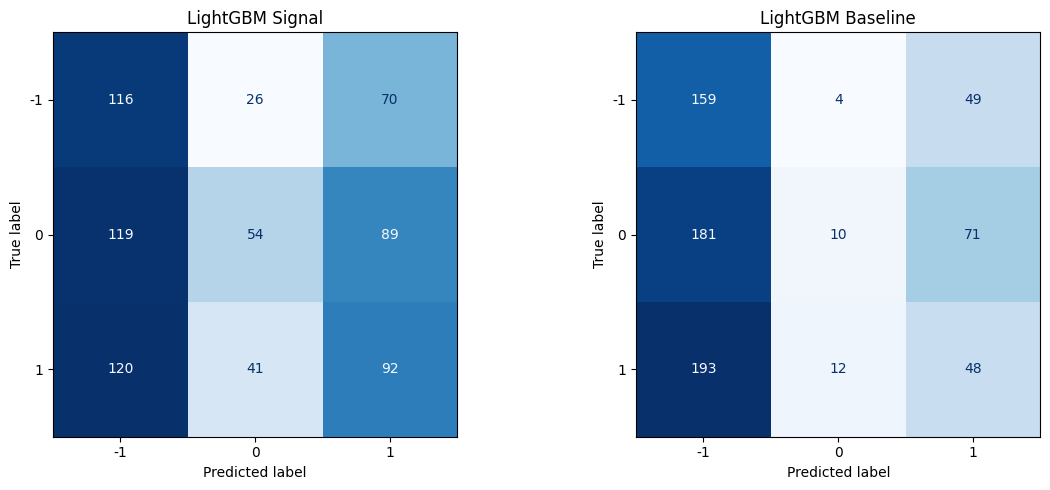

In [29]:
visualization.plot_confusion_matrices(
    models_dict={
        "LightGBM Signal": (signal_best_lgbm, test_signal_X),
        "LightGBM Baseline": (baseline_best_lgbm, test_baseline_X),
    },
    y_test=y_test_signal,
    label_encoder=label_encoder,
)


,Total Return,Average Return,Volatility,Sharpe (annualised),Sortino (annualised),Max Drawdown,Win Rate (%),Number of Trades
Strategy,,,,,,,,
LightGBM Signal (with news),2859.06,3.932682,19.951723,18.448476,27.598617,-519.79,57.589286,672
LightGBM Baseline (price-only),2357.22,3.242393,20.320939,14.933926,23.047779,-651.10,54.470426,727
Naive Buy-DA/Sell-Spot,1044.42,1.436616,20.528065,6.550053,8.873426,-1399.64,52.132050,727


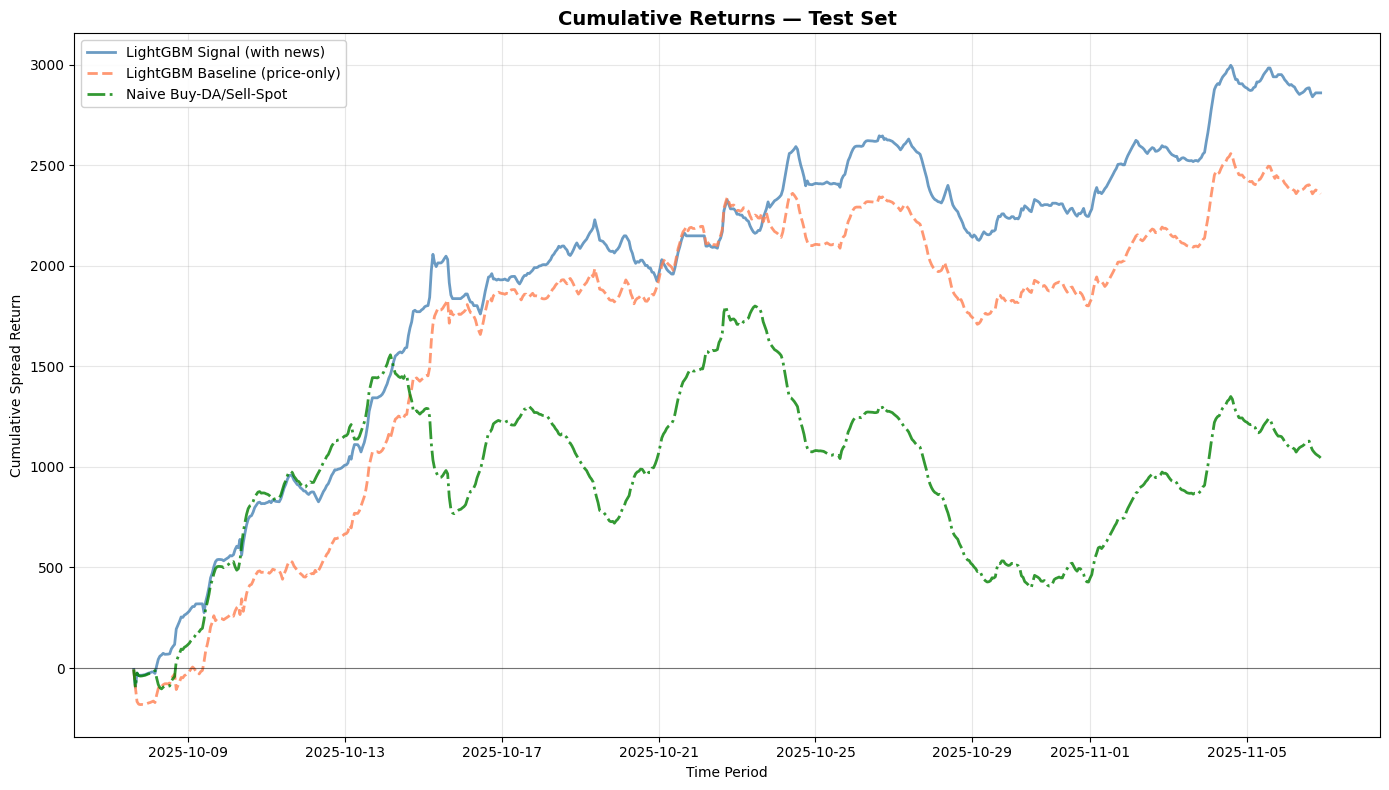

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Cumulative Returns — Test Set'}, xlabel='Time Period', ylabel='Cumulative Spread Return'>)

In [30]:
spot_col = evaluation.get_column_name([
    "Spot Price", "spot_price", "SpotPrice"
], signal_test_df)
day_ahead_col = evaluation.get_column_name([
    "Day Ahead Auction", "day_ahead_price", "DayAhead"
], signal_test_df)

if spot_col is None or day_ahead_col is None:
    raise KeyError("Could not identify spot or day-ahead price columns for backtesting.")

spot_series = signal_test_df[spot_col]
day_ahead_series = signal_test_df[day_ahead_col]
spread_series = spot_series - day_ahead_series

strategy_actions = {
    "LightGBM Signal (with news)": signal_test_decoded,
    "LightGBM Baseline (price-only)": baseline_test_decoded,
    "Naive Buy-DA/Sell-Spot": np.ones_like(signal_test_decoded, dtype=int),
}

strategy_returns = evaluation.compute_strategy_returns(strategy_actions, spread_series)
returns_summary = evaluation.summarise_strategy_set(strategy_returns)

display(returns_summary)

# Plot cumulative returns
visualization.plot_cumulative_returns(
    returns_map=strategy_returns,
    title="Cumulative Returns — Test Set",
    ylabel="Cumulative Spread Return",
)


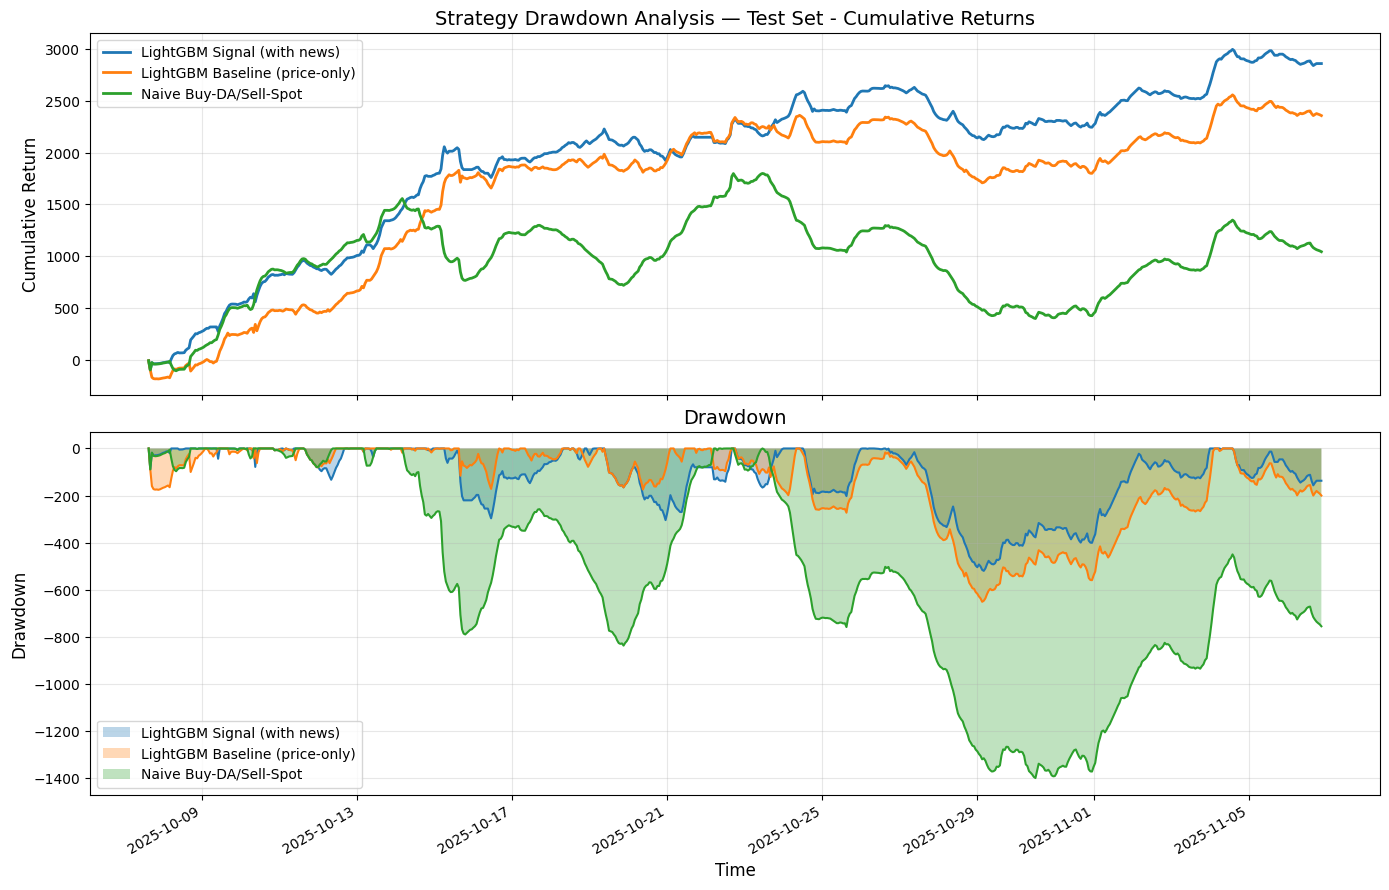

In [31]:
# Plot drawdown analysis
visualization.plot_drawdown_chart(
    returns_map=strategy_returns,
    title="Strategy Drawdown Analysis — Test Set"
)


,Total Return,Average Return,Volatility,Sharpe (annualised),Sortino (annualised),Max Drawdown,Win Rate (%),Number of Trades
Strategy,,,,,,,,
LightGBM Signal (with news),2859.06,3.932682,19.951723,18.448476,27.598617,-519.79,57.589286,672
LightGBM Baseline (price-only),2357.22,3.242393,20.320939,14.933926,23.047779,-651.10,54.470426,727
Naive Buy-DA/Sell-Spot,1044.42,1.436616,20.528065,6.550053,8.873426,-1399.64,52.132050,727


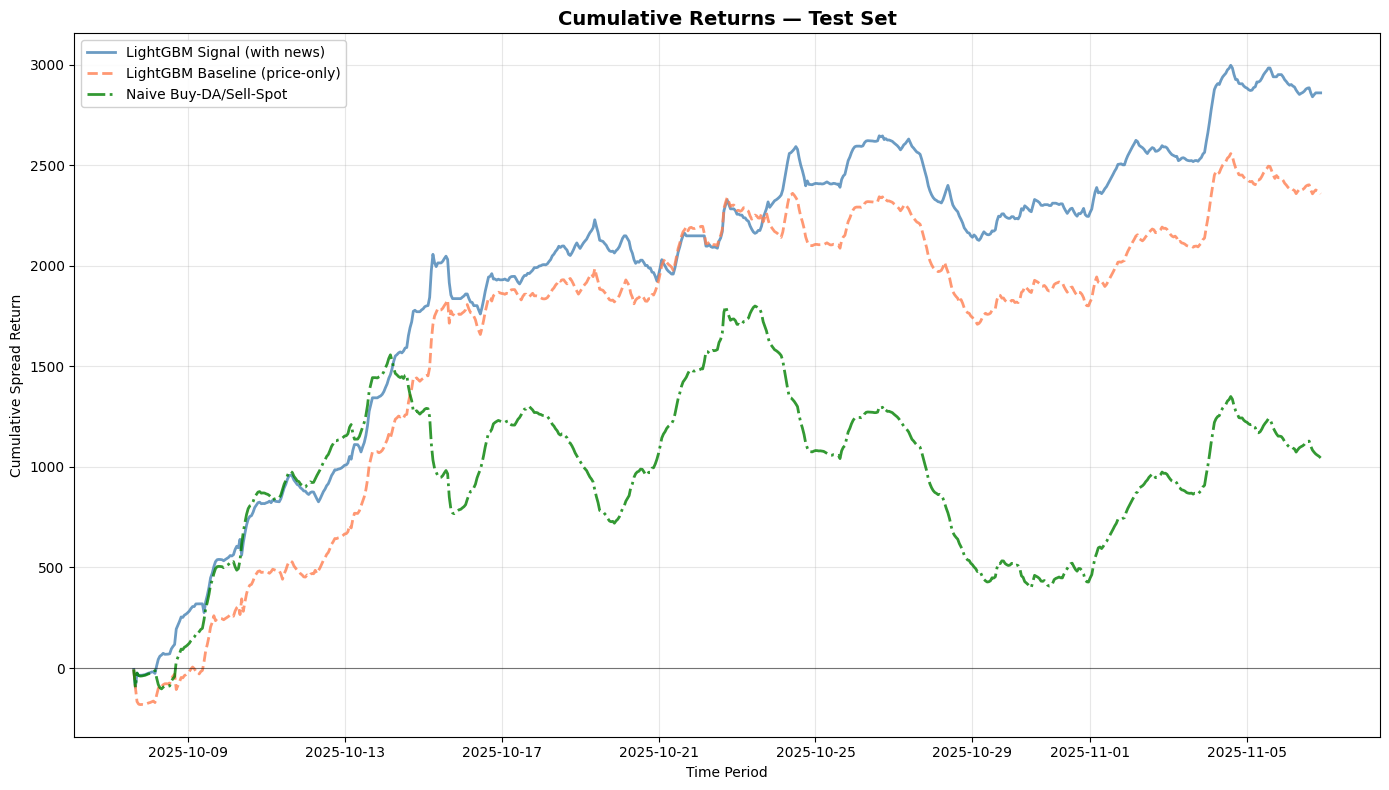

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Cumulative Returns — Test Set'}, xlabel='Time Period', ylabel='Cumulative Spread Return'>)

In [32]:
# Setup backtest strategies
spread_series, strategy_actions = evaluation.setup_backtest_strategies(
    test_df=signal_test_df,
    signal_predictions=signal_test_pred,
    baseline_predictions=baseline_test_pred,
    label_encoder=label_encoder
)

# Compute and display strategy returns
strategy_returns = evaluation.compute_strategy_returns(strategy_actions, spread_series)
returns_summary = evaluation.summarise_strategy_set(strategy_returns)
display(returns_summary)

# Plot cumulative returns
visualization.plot_cumulative_returns(
    returns_map=strategy_returns,
    title="Cumulative Returns — Test Set",
    ylabel="Cumulative Spread Return",
)


BACKTESTING WITH TRANSACTION COSTS

No Costs:
  Fixed: €0.0/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          2859.06            18.448476             27.598617
LightGBM Baseline (price-only)       2357.22            14.933926             23.047779
Naive Buy-DA/Sell-Spot               1044.42             6.550053              8.873426

Low Cost (€0.5/MWh):
  Fixed: €0.5/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          2523.06            16.286128             24.426330
LightGBM Baseline (price-only)       1993.72            12.631009             19.554503
Naive Buy-DA/Sell-Spot                680.92             4.2703

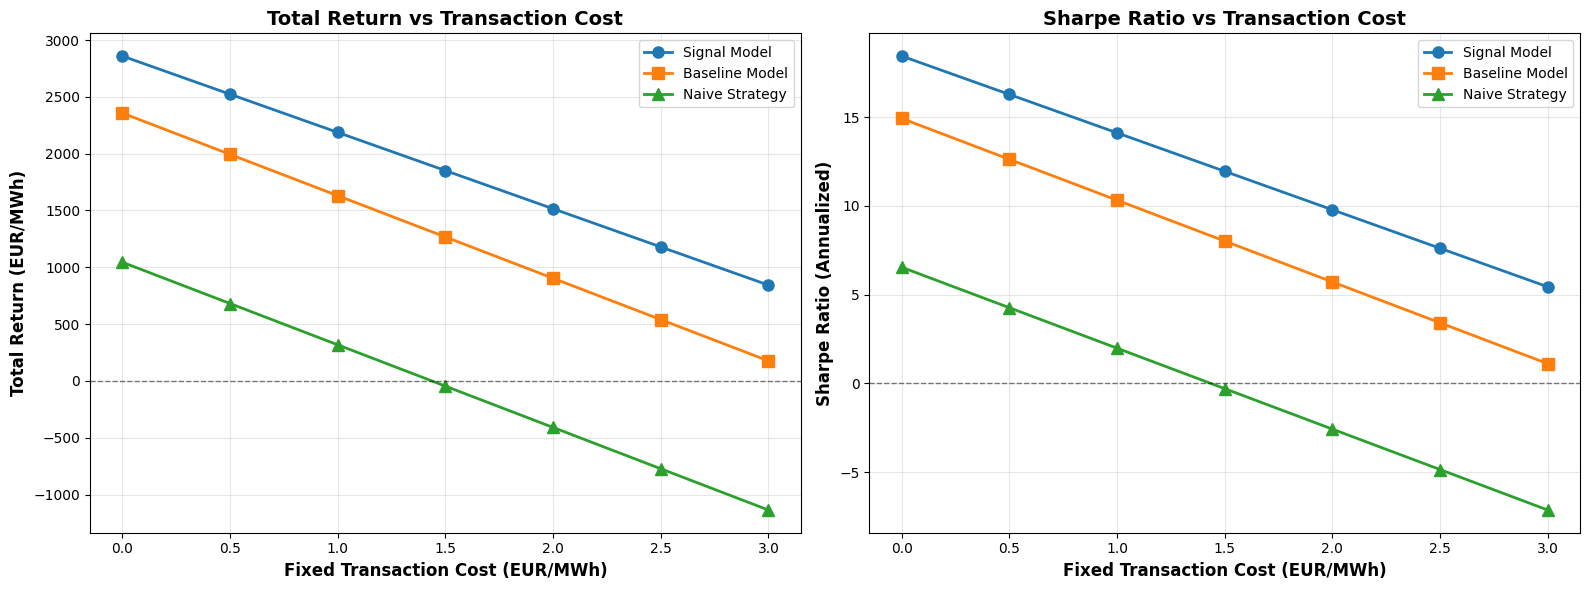

In [33]:
# Evaluate strategies with transaction costs
print("\n" + "=" * 80)
print("BACKTESTING WITH TRANSACTION COSTS")
print("=" * 80)

# Define transaction cost scenarios
transaction_cost_scenarios = {
    "No Costs": (0.0, 0.0),
    "Low Cost (€0.5/MWh)": (0.5, 0.0),
    "Medium Cost (€1.0/MWh)": (1.0, 0.0),
    "High Cost (€2.0/MWh + 0.1%)": (2.0, 0.001),
}

# Compute returns for each scenario
for scenario_name, (fixed_cost, pct_cost) in transaction_cost_scenarios.items():
    print(f"\n{scenario_name}:")
    print(f"  Fixed: €{fixed_cost}/MWh, Percentage: {pct_cost*100:.2f}%")
    
    strategy_returns_cost = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=fixed_cost,
        transaction_cost_pct=pct_cost
    )
    
    returns_summary_cost = evaluation.summarise_strategy_set(strategy_returns_cost)
    print(f"\n{returns_summary_cost[['Total Return', 'Sharpe (annualised)', 'Sortino (annualised)']].to_string()}")

# Visualize impact of transaction costs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total return vs transaction cost
costs = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
signal_returns = []
baseline_returns = []
naive_returns = []

for cost in costs:
    temp_returns = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=cost,
        transaction_cost_pct=0.0
    )
    signal_returns.append(temp_returns["LightGBM Signal (with news)"].sum())
    baseline_returns.append(temp_returns["LightGBM Baseline (price-only)"].sum())
    naive_returns.append(temp_returns["Naive Buy-DA/Sell-Spot"].sum())

ax1.plot(costs, signal_returns, 'o-', linewidth=2, markersize=8, label='Signal Model')
ax1.plot(costs, baseline_returns, 's-', linewidth=2, markersize=8, label='Baseline Model')
ax1.plot(costs, naive_returns, '^-', linewidth=2, markersize=8, label='Naive Strategy')
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Fixed Transaction Cost (EUR/MWh)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Total Return (EUR/MWh)', fontweight='bold', fontsize=12)
ax1.set_title('Total Return vs Transaction Cost', fontweight='bold', fontsize=14)
ax1.legend(loc='best')
ax1.grid(alpha=0.3)

# Right: Sharpe ratio vs transaction cost
signal_sharpes = []
baseline_sharpes = []
naive_sharpes = []

for cost in costs:
    temp_returns = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=cost,
        transaction_cost_pct=0.0
    )
    temp_summary = evaluation.summarise_strategy_set(temp_returns)
    signal_sharpes.append(temp_summary.loc["LightGBM Signal (with news)", "Sharpe (annualised)"])
    baseline_sharpes.append(temp_summary.loc["LightGBM Baseline (price-only)", "Sharpe (annualised)"])
    naive_sharpes.append(temp_summary.loc["Naive Buy-DA/Sell-Spot", "Sharpe (annualised)"])

ax2.plot(costs, signal_sharpes, 'o-', linewidth=2, markersize=8, label='Signal Model')
ax2.plot(costs, baseline_sharpes, 's-', linewidth=2, markersize=8, label='Baseline Model')
ax2.plot(costs, naive_sharpes, '^-', linewidth=2, markersize=8, label='Naive Strategy')
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Fixed Transaction Cost (EUR/MWh)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Sharpe Ratio (Annualized)', fontweight='bold', fontsize=12)
ax2.set_title('Sharpe Ratio vs Transaction Cost', fontweight='bold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)

# Feature importance for both models
visualization.plot_feature_importance(model=signal_best_lgbm, feature_names=signal_feature_columns_sanitized, model_name="LightGBM Signal Model", top_n=20)
visualization.plot_feature_importance(model=baseline_best_lgbm, feature_names=baseline_feature_columns_sanitized, model_name="LightGBM Baseline Model", top_n=20)


BACKTESTING WITH TRANSACTION COSTS

No Costs:
  Fixed: €0.0/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          2859.06            18.448476             27.598617
LightGBM Baseline (price-only)       2357.22            14.933926             23.047779
Naive Buy-DA/Sell-Spot               1044.42             6.550053              8.873426

Low Cost (€0.5/MWh):
  Fixed: €0.5/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          2523.06            16.286128             24.426330
LightGBM Baseline (price-only)       1993.72            12.631009             19.554503
Naive Buy-DA/Sell-Spot                680.92             4.2703

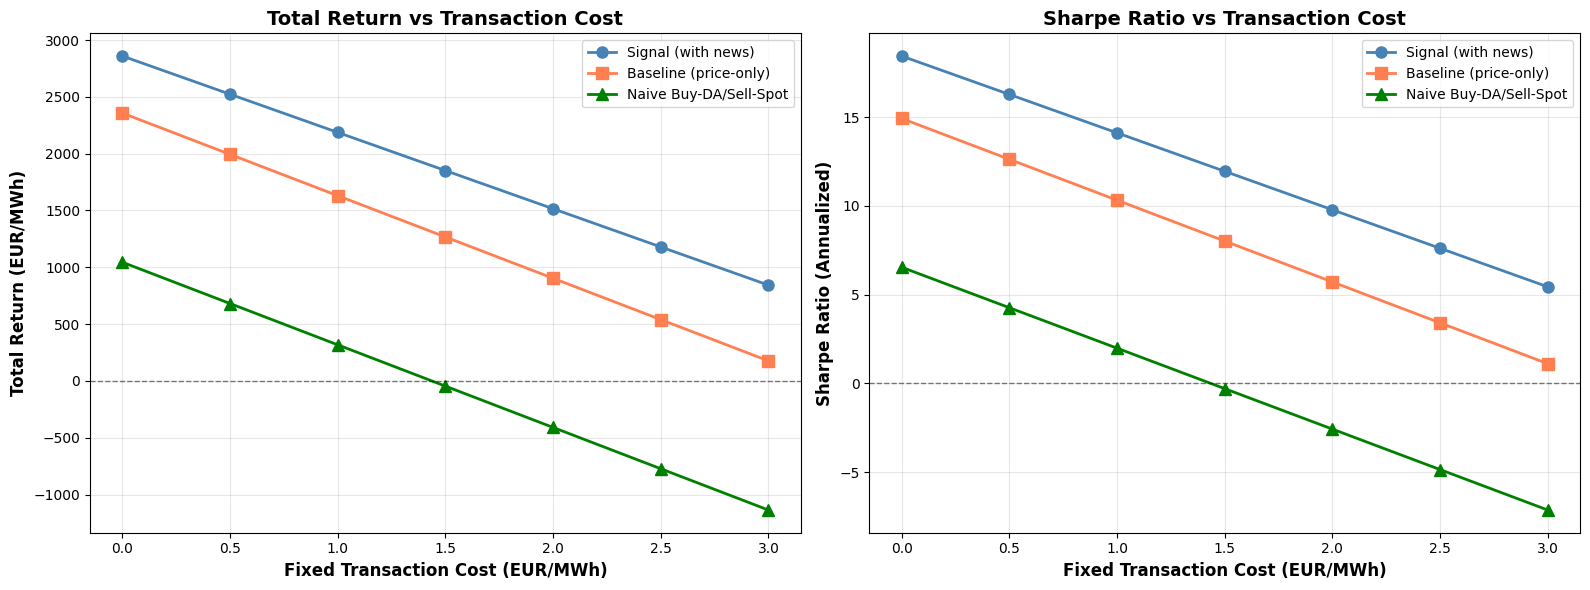

In [34]:
# Transaction cost sensitivity analysis
visualization.plot_transaction_cost_sensitivity(
    strategy_actions=strategy_actions,
    spread_series=spread_series
)